<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
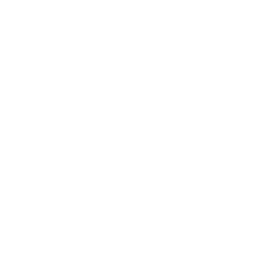
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Insurance Claim Severity Ranking</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Insurance / Claims Reserving &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Rank open property and casualty insurance claims by severity amount to prioritize loss reserve allocation and adjuster assignment. PROC RANK with TIES=MEAN assigns each claim a continuous severity rank, averaging the rank of any claims that share an identical incurred amount so no claim is arbitrarily favored. The ranks drive a four-tier priority classification and a Pareto severity chart for the quarterly reserve committee, supporting the actuarial workflow in which the most severe claims concentrate the bulk of incurred losses and required reserves.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.OPEN_CLAIMS | Active open claims with incurred amounts | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic open insurance claims
   Mix of property and casualty lines
   -------------------------------------------------------- */
data work.open_claims;
    call streaminit(42);
    array lob_list[4] $20 _temporary_ ('AUTO_LIABILITY' 'HOMEOWNERS' 'COMMERCIAL_PROP' 'WORKERS_COMP');
    array status_list[3] $10 _temporary_ ('OPEN' 'RESERVED' 'LITIGATED');
    array adjuster_list[8] $6 _temporary_ ('ADJ-01' 'ADJ-02' 'ADJ-03' 'ADJ-04' 'ADJ-05' 'ADJ-06' 'ADJ-07' 'ADJ-08');
    do claim_seq = 1 to 100;
        claim_id = cat('CLM-', put(2026000 + claim_seq, z7.));
        policy_id = cat('POL-', put(int(rand('uniform') * 10000) + 1, z6.));
        lob_idx = int(rand('uniform') * 4) + 1;
        line_of_business = lob_list[lob_idx];
        stat_idx = int(rand('uniform') * 3) + 1;
        claim_status = status_list[stat_idx];
        adj_idx = int(rand('uniform') * 8) + 1;
        adjuster_id = adjuster_list[adj_idx];
        loss_date = '01JUL2025'd + int(rand('uniform') * 250);
        report_date = loss_date + int(rand('exponential') * 15);
        /* Severity: heavy right tail with occasional large losses */
        incurred_amount = round(rand('exponential') * 8000 + 500, 0.01);
        if rand('uniform') > 0.92 then
            incurred_amount = incurred_amount * int(rand('uniform') * 8 + 3);
        paid_amount = round(incurred_amount * rand('uniform') * 0.6, 0.01);
        reserve_amount = round(incurred_amount - paid_amount, 0.01);
        claimant_state = substr('CATXNYFLIJOHPAMIVA', int(rand('uniform') * 9) * 2 + 1, 2);
        output;
    end;
    drop lob_idx stat_idx adj_idx claim_seq;
    format loss_date report_date date9.
           incurred_amount paid_amount reserve_amount dollar12.2;
run;

NOTE: DATA work.open_claims


NOTE: Wrote work.open_claims (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline claim severity by line of business
   -------------------------------------------------------- */
proc means data=work.open_claims n sum mean std max;
    class line_of_business;
    var incurred_amount reserve_amount;
run;

                                                  The MEANS Procedure

                                          Analysis Variable : incurred_amount

        line_of_business          N Obs            Sum           Mean        Std Dev        Maximum
        -------------------------------------------------------------------------------------------
        AUTO_LIABILITY               27    $295,043.59     $10,927.54     $10,581.11     $49,315.23
        COMMERCIAL_PROP              26    $201,956.25      $7,767.55      $6,584.02     $28,133.77
        HOMEOWNERS                   23    $355,697.53     $15,465.11     $26,876.98    $126,792.90
        WORKERS_COMP                 24    $229,634.55      $9,568.11     $11,560.79     $45,395.58
        -------------------------------------------------------------------------------------------

                                           Analysis Variable : reserve_amount

        line_of_business          N Obs            Sum           Mean 

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

NOTE: PROC SGPLOT data=work.open_claims

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


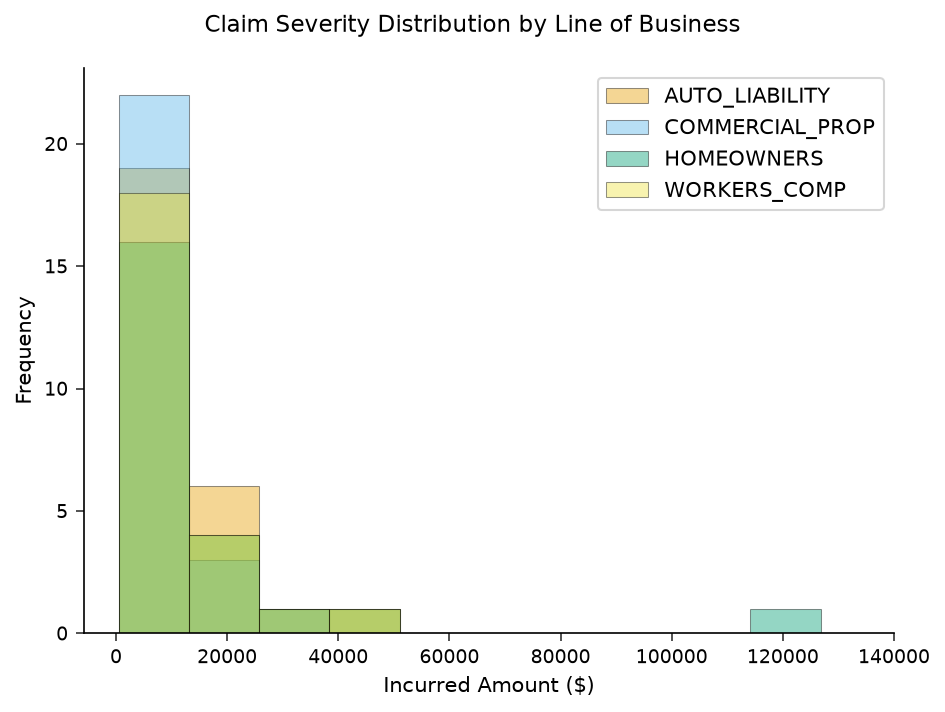

In [3]:
/* --------------------------------------------------------
   Claim severity distribution by line of business
   -------------------------------------------------------- */
proc sgplot data=work.open_claims;
    histogram incurred_amount / group=line_of_business transparency=0.4;
    xaxis label='Incurred Amount ($)' max=140000;
    yaxis label='Frequency';
    title 'Claim Severity Distribution by Line of Business';
run;

---

In [4]:
/* --------------------------------------------------------
   Rank claims by incurred amount (severity).
   TIES=MEAN assigns the average rank when claims have
   identical incurred amounts, producing a fair continuous
   rank for downstream analysis.
   -------------------------------------------------------- */
proc rank data=work.open_claims out=work.claims_ranked ties=mean;
    var incurred_amount;
    ranks severity_rank;
run;

NOTE: PROC RANK data=work.open_claims out=Some("work.claims_ranked")


NOTE: Read 100 rows from ./work/3cdaa46b-e256-4e8c-93c0-d883ea261f09/open_claims.avro.
NOTE: Wrote ./work/3cdaa46b-e256-4e8c-93c0-d883ea261f09/claims_ranked.avro (100 rows, 12 columns).
NOTE: PROC RANK elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [5]:
/* --------------------------------------------------------
   Compute severity percentile from rank for reporting.
   Identify top-20% claims driving reserve concentration.
   -------------------------------------------------------- */
data work.claims_prioritized;
    set work.claims_ranked nobs=total_claims;
    severity_pctl = round(severity_rank / total_claims * 100, 0.1);
    length priority_tier $10;
    if severity_pctl >= 80 then priority_tier = 'CRITICAL';
    else if severity_pctl >= 60 then priority_tier = 'HIGH';
    else if severity_pctl >= 40 then priority_tier = 'MEDIUM';
    else priority_tier = 'LOW';
run;

NOTE: DATA work.claims_prioritized


NOTE: Read 100 rows from work.claims_ranked.
NOTE: Wrote work.claims_prioritized (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


NOTE: PROC SORT data=work.claims_prioritized

NOTE: Read 100 rows from work.claims_prioritized.
NOTE: Wrote work.claims_prioritized (100 rows, 15 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.claims_pareto


NOTE: Read 100 rows from work.claims_prioritized.
NOTE: Wrote work.claims_pareto (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.claims_pareto

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


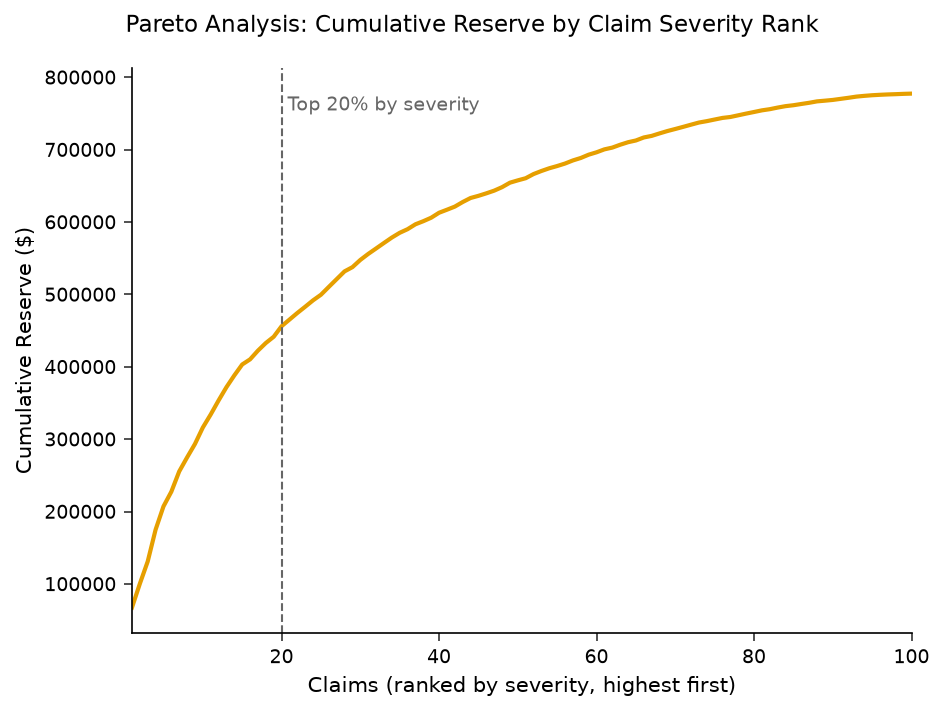

In [6]:
/* --------------------------------------------------------
   Pareto chart: cumulative reserve by severity rank
   -------------------------------------------------------- */
proc sort data=work.claims_prioritized;
    by descending severity_rank;
run;

data work.claims_pareto;
    set work.claims_prioritized;
    retain cum_reserve 0 cum_count 0;
    cum_count + 1;
    cum_reserve + reserve_amount;
run;

proc sgplot data=work.claims_pareto;
    series x=cum_count y=cum_reserve / lineattrs=(thickness=2);
    refline 20 / axis=x label='Top 20% by severity' lineattrs=(pattern=dash);
    xaxis label='Claims (ranked by severity, highest first)';
    yaxis label='Cumulative Reserve ($)';
    title 'Pareto Analysis: Cumulative Reserve by Claim Severity Rank';
run;

In [7]:
/* --------------------------------------------------------
   Summary of priority tiers for reserve committee
   -------------------------------------------------------- */
proc means data=work.claims_prioritized n sum mean;
    class priority_tier;
    var incurred_amount reserve_amount;
    output out=work.tier_summary
        n=n_claims sum=total_incurred mean=avg_incurred;
run;

                                                  The MEANS Procedure

                                          Analysis Variable : incurred_amount

        priority_tier          N Obs            Sum           Mean
        ----------------------------------------------------------
        CRITICAL                  21    $643,133.12     $30,625.39
        HIGH                      20    $214,780.12     $10,739.01
        LOW                       39    $103,739.86      $2,660.00
        MEDIUM                    20    $120,678.82      $6,033.94
        ----------------------------------------------------------

                                           Analysis Variable : reserve_amount

        priority_tier          N Obs            Sum           Mean
        ----------------------------------------------------------
        CRITICAL                  21    $465,256.68     $22,155.08
        HIGH                      20    $151,804.13      $7,590.21
        LOW                      

NOTE: PROC MEANS
NOTE: Output dataset work.tier_summary has 5 observations and 8 variables.
NOTE: PROC MEANS statement used.


---

### Interpretation

PROC RANK assigned continuous severity ranks (1 = smallest incurred amount, 100 = largest) to all 100 open claims. The incurred amounts were distinct, so the TIES=MEAN policy resolved to ordinary integer ranks here; it remains the safe default for production runs where duplicate round-number reserves are common. Mapping each rank to a severity percentile produced four priority tiers, and the tier summary makes the concentration explicit: the CRITICAL tier (the 21 claims at or above the 80th severity percentile) carries \$465K of the \$778K total reserve portfolio — about 60% of reserves and 59% of incurred loss held in roughly the top 21% of claims, the classic heavy-tail concentration that drives loss-reserve adequacy testing. The Pareto chart traces this directly: cumulative reserve rises steeply across the highest-ranked claims and then flattens, with the dashed reference line marking the top 20% by severity. The single largest claim is a \$126,793 incurred HOMEOWNERS loss (\$67,372 reserved), the visible right-tail outlier in the severity histogram. Line of business is mixed within the CRITICAL tier — AUTO_LIABILITY leads at 7 of 21 claims, with HOMEOWNERS and WORKERS_COMP next — so severity, not a single coverage line, governs prioritization. The ranked, tiered output gives the reserve committee a defensible framework for directing senior-adjuster attention and reserve scrutiny to the claims that matter most.

---

In [8]:
/* --------------------------------------------------------
   Export prioritized claims for adjuster assignment
   -------------------------------------------------------- */
proc export data=work.claims_prioritized
    outfile='claims_severity_ranked.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.claims_prioritized outfile=claims_severity_ranked.csv

NOTE: Exported 100 rows to claims_severity_ranked.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>